In [1]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path as P
r = P.cwd() if (P.cwd() / "src").exists() else P.cwd().parent
sys.path[:0] = [str(r / "src"), str(r)]
from simulation_scripts.execute_simulations import *
from retrieval_methods.inline_retrieval import *


# Load Simulation Parameters

In [2]:
param_card_dict = np.load("../data/param_cards/Param_Card_PBI_Mono.npy", allow_pickle=True)

pd.DataFrame(param_card_dict.item().items(), columns=["Parameter", "Value"])

,Parameter,Value
0,Type of spectrum,Mono
1,Source geometry,Parallel
2,Energy (keV),20
3,Focal spot size (μm),0
4,Sim. pixel (μm),1
5,FOV (pix),"(300,300)"
6,Num. events per pixel,5000
7,Binning factor,10
8,FWHM PSF (pix),2
9,Geometry,fibre


# Calculate Reference Image

Obtaining reference and sample images for Energy = 21.0 keV


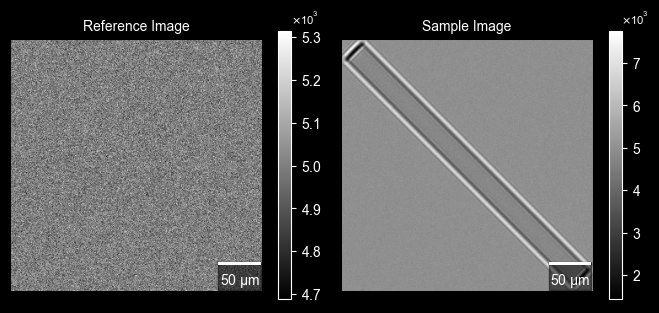

In [3]:
show_reference_Inline(param_card_dict.item())

# Save Reference (Flat-Field) and Sample Images 

In [4]:
run_Inline_sim(param_card_dict.item(), save_path="../results/PBI_Mono/")

Running simulation...
Obtaining reference and sample images for Energy = 20.0 keV
Simulation finished.


# Retrieve and Plot Transmission Image

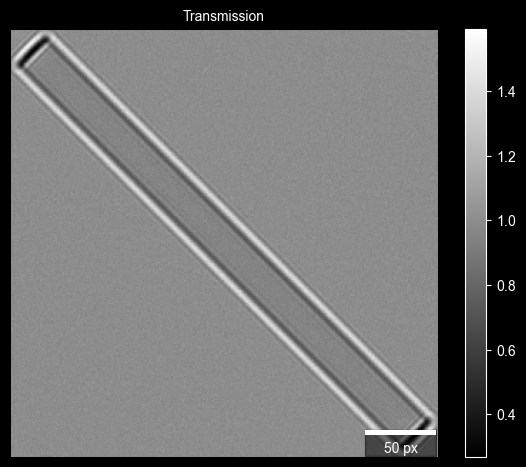

In [5]:
Iref = np.load("../results/PBI_Mono/I_ref_poly.npy")
Isamp = np.load("../results/PBI_Mono/I_samp_poly.npy")
params = None
get_retrieved_images(Iref, Isamp, params)